# **MediaPipePose 2D Keypoints Anthro Angle Stereo Distance**

## **Pipeline**
* Use MediaPipePose to get 2D keypoints (pixel coordinates)
* Use StereoSGBM to get distance from camera to shoulder joint
* Use arm length to determine output vector

### **Setup**

```
conda create -n fbv-media-pipe-pose python=3.10
conda activate fbv-media-pipe-pose
pip install mediapipe opencv-python
pip install ipympl
conda install ipykernel=6.29.5
```

In [166]:
import cv2
import numpy as np
import json
import time

In [167]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision

In [168]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [169]:
%matplotlib widget

In [170]:
IMAGE_A_PATH = "../../../dataset/images_A/00001A.png"
IMAGE_B_PATH = "../../../dataset/images_B/00001B.png"
JSON_A_PATH = "../../../dataset/metadata_A/00001A.json"
MODEL_PATH = "../../models/pose_landmarker_full.task"

FOCAL_LENGTH_MM = 35.0
SENSOR_WIDTH_MM = 36.0 
BASELINE_M = 0.1

### **Sample Image**

Image Shape: (1080, 1920, 3)


C:\Users\ExoHorizon\AppData\Local\Temp\ipykernel_20652\145544115.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(6, 3), layout="constrained")


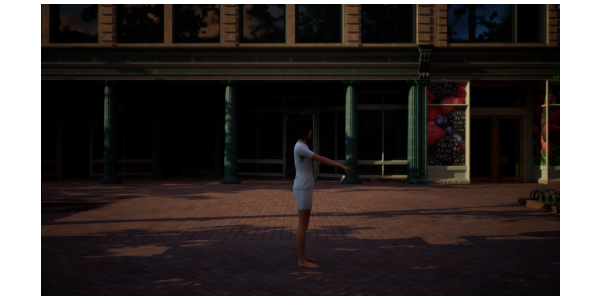

In [171]:
# Load & Preview Sample Image
image = cv2.imread(IMAGE_A_PATH)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(f"Image Shape: {image.shape}")

fig = plt.figure(figsize=(6, 3), layout="constrained")
plt.imshow(image)
plt.axis('off')
plt.show()

### **Keypoint Regression (CPU)**

In [172]:
# Create PoseLandmarker Object

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(base_options=base_options)
detector = vision.PoseLandmarker.create_from_options(options)

In [173]:
# Detect Keypoints

start_time = time.perf_counter()

mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image)
detection_result = detector.detect(mp_image)

end_time = time.perf_counter()

execution_time = end_time - start_time
print(f"Detection took: {execution_time:.4f} seconds")
print(f"FPS: {1/execution_time:.2f}")

Detection took: 0.0230 seconds
FPS: 43.53


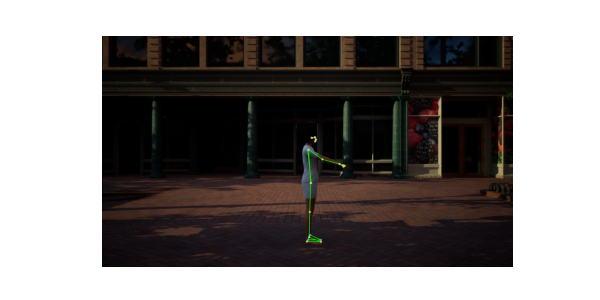

In [174]:
# Show Annotated Image (Pixel Coordinates)

# Helper Util from: https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker
def draw_landmarks_on_image(rgb_image, detection_result):
    pose_landmarks_list = detection_result.pose_landmarks
    annotated_image = np.copy(rgb_image)

    pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
    pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

    for pose_landmarks in pose_landmarks_list:
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=pose_landmarks,
            connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
            landmark_drawing_spec=pose_landmark_style,
            connection_drawing_spec=pose_connection_style)

    return annotated_image

annotated_image = draw_landmarks_on_image(mp_image.numpy_view(), detection_result)
plt.figure(figsize=(6, 3))
plt.imshow(annotated_image)
plt.axis('off')
plt.show()

### **Convert To Numpy**

In [175]:
# Create Numpy Arrays

landmarks_2d = detection_result.pose_landmarks
keypoints_2d = np.array([[lm.x, lm.y] for lm in landmarks_2d[0]]) if landmarks_2d else np.zeros((33, 2))

### **Compute Disparity Map**

In [176]:
# Load & Crop Images

image_A = cv2.imread(IMAGE_A_PATH)
image_B = cv2.imread(IMAGE_B_PATH)

gray_A_full = cv2.cvtColor(image_A, cv2.COLOR_BGR2GRAY)
gray_B_full = cv2.cvtColor(image_B, cv2.COLOR_BGR2GRAY)

In [177]:
# Crop Images

h, w = 480, 480
y_start, x_start = 300, 720

gray_A = gray_A_full[y_start:y_start+h, x_start:x_start+w]
gray_B = gray_B_full[y_start:y_start+h, x_start:x_start+w]

In [178]:
# Initialize SGBM object

stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=160,
    blockSize=5,
    P1=8 * 3 * 5**2,
    P2=32 * 3 * 5**2,
    disp12MaxDiff=1,
    uniquenessRatio=15,
    speckleWindowSize=0,
    speckleRange=2,
    preFilterCap=63,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
)

In [179]:
# Compute Disparity

start_time = time.perf_counter()

disparity = stereo.compute(gray_A, gray_B).astype(np.float32) / 16.0

end_time = time.perf_counter()

execution_time = end_time - start_time
print(f"Disparity took: {execution_time:.4f} seconds")
print(f"FPS: {1/execution_time:.2f}")

Disparity took: 0.0086 seconds
FPS: 115.72


### **Calculate Camera-Shoulder Distance**

In [180]:
# Get Predicted Right Shoulder Pixel Location

height, width = disparity.shape

shoulder_kp_2d = keypoints_2d[12]

px_x = int(np.clip(shoulder_kp_2d[0] * width, 0, width - 1))
px_y = int(np.clip(shoulder_kp_2d[1] * height, 0, height - 1))

window = disparity[px_y-2:px_y+3, px_x-2:px_x+3]
disp_at_shoulder = np.nanmedian(window) if np.any(window) else 0

print(disp_at_shoulder)

31.0


In [181]:
# Calculate Focal Length

image_width_px = 1920
focal_length_px = (FOCAL_LENGTH_MM * image_width_px) / SENSOR_WIDTH_MM

In [182]:
# Distance Output

distance_shoulder = None
if disp_at_shoulder > 0:
    distance_shoulder = (focal_length_px * BASELINE_M) / disp_at_shoulder
    print(f"Distance to shoulder: {distance_shoulder:.3f} meters")
else:
    print("Distance calculation failed: Disparity is zero or negative at center.")

Distance to shoulder: 6.022 meters


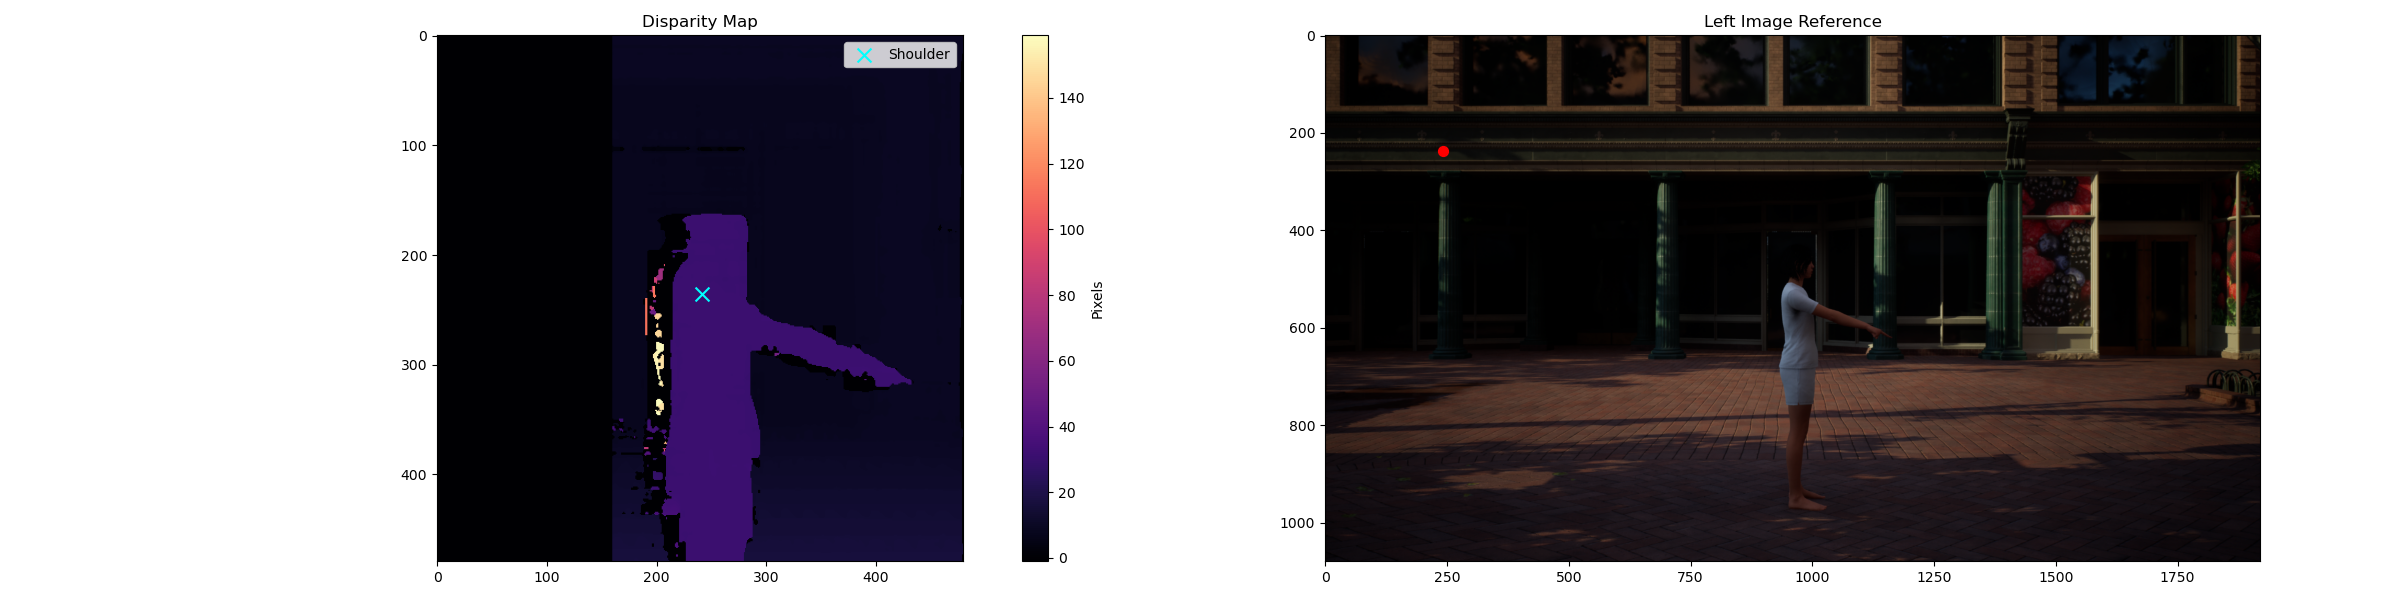

In [183]:
# Visualize Disparity

plt.figure(figsize=(24, 6))

plt.subplot(1, 2, 1)
plt.title("Disparity Map")
plt.imshow(disparity, cmap='magma')
plt.colorbar(label='Pixels')
plt.scatter(px_x, px_y, color='cyan', marker='x', s=100, label='Shoulder')
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Left Image Reference")
plt.imshow(cv2.cvtColor(image_A, cv2.COLOR_BGR2RGB))
plt.scatter(px_x, px_y, color='red', marker='o', s=50)

plt.tight_layout()
plt.show()

### **Calculate Camera-Wrist Distance**

In [184]:
# Get Predicted Right Shoulder Pixel Location

height, width = disparity.shape

wrist_kp_2d = keypoints_2d[16]

px_x = int(np.clip(wrist_kp_2d[0] * width, 0, width - 1))
px_y = int(np.clip(wrist_kp_2d[1] * height, 0, height - 1))

window = disparity[px_y-2:px_y+3, px_x-2:px_x+3]
disp_at_wrist = np.nanmedian(window) if np.any(window) else 0

print(disp_at_wrist)

31.0625


In [185]:
# Distance Output

distance_wrist = None
if disp_at_wrist > 0:
    distance_wrist = (focal_length_px * BASELINE_M) / disp_at_wrist
    print(f"Distance to wrist: {distance_wrist:.3f} meters")
else:
    print("Distance calculation failed: Disparity is zero or negative at center.")

Distance to wrist: 6.009 meters


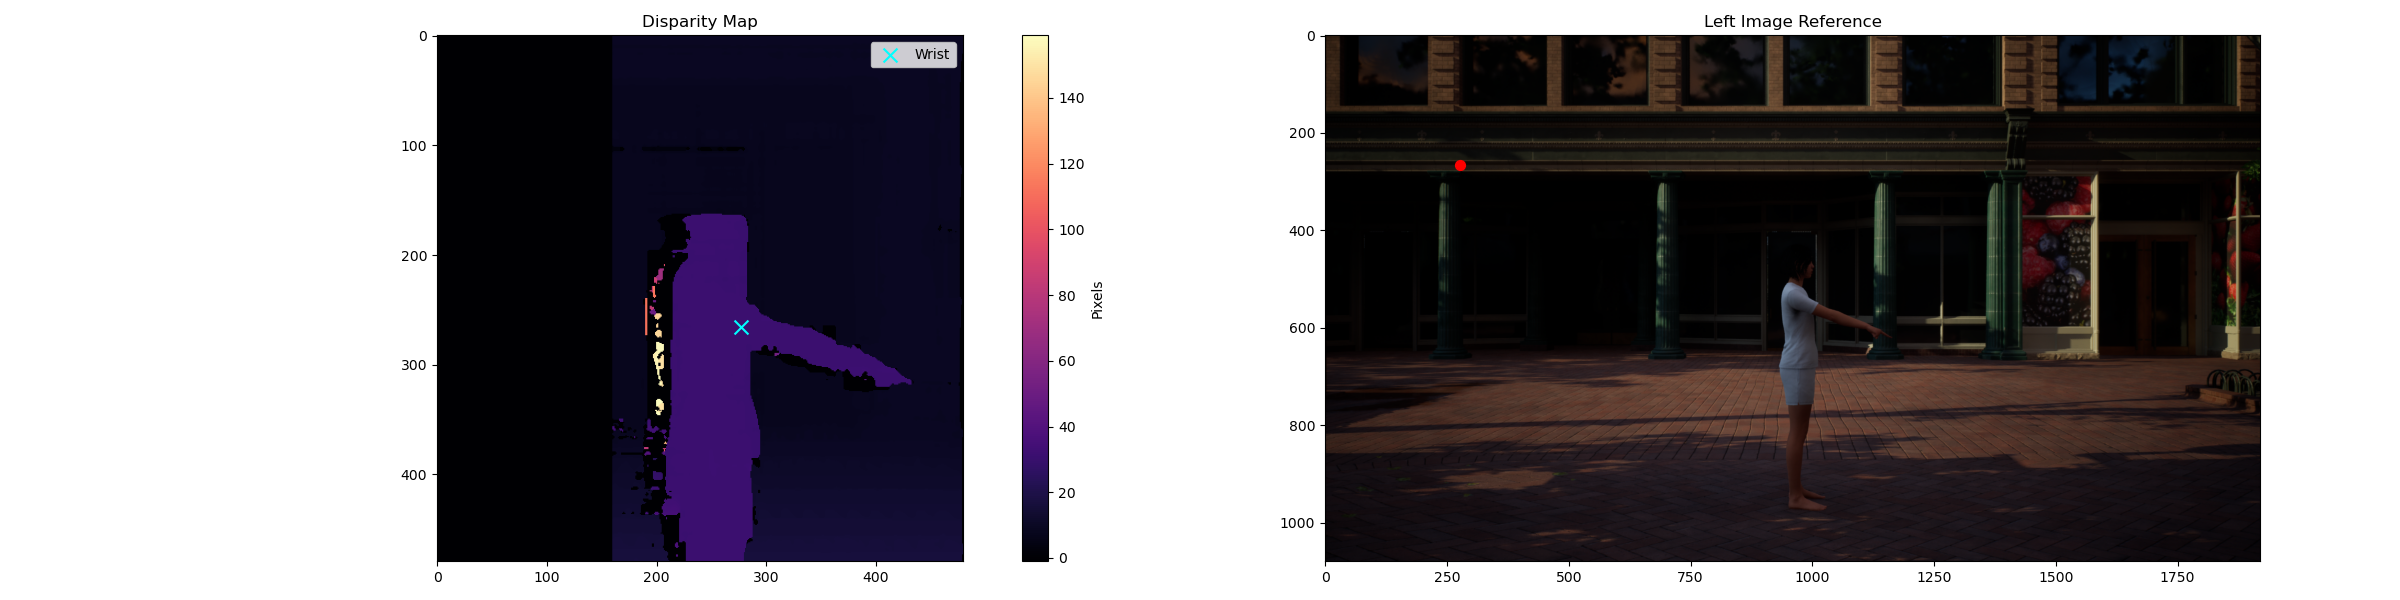

In [186]:
# Visualize Disparity

plt.figure(figsize=(24, 6))

plt.subplot(1, 2, 1)
plt.title("Disparity Map")
plt.imshow(disparity, cmap='magma')
plt.colorbar(label='Pixels')
plt.scatter(px_x, px_y, color='cyan', marker='x', s=100, label='Wrist')
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Left Image Reference")
plt.imshow(cv2.cvtColor(image_A, cv2.COLOR_BGR2RGB))
plt.scatter(px_x, px_y, color='red', marker='o', s=50)

plt.tight_layout()
plt.show()

### **Calculate Arm Length**

In [187]:
# Load JSON Metadata

with open(JSON_A_PATH, 'r') as file:
    raw_data = json.load(file)

data = {
    'RS': np.array([raw_data['Right Shoulder Coords'][axis] for axis in ['x', 'y', 'z']]),
    'RW': np.array([raw_data['Right Wrist Coords'][axis] for axis in ['x', 'y', 'z']]),
}

print(data)

{'RS': array([-4581.53774476,  -185.47113061,   141.47604939]), 'RW': array([-4528.30575964,  -185.76802202,   141.55266454])}


In [188]:
# Get Ground Truth Arm Length

arm_length = np.linalg.norm(data['RS'] - data['RW']) / 100
print(arm_length)

0.5323286817042233


In [189]:
# Define Rays

def get_3d_direction(kp_2d, focal_px, img_w, img_h):
    x = (kp_2d[0] * img_w) - (img_w / 2)
    y = (kp_2d[1] * img_h) - (img_h / 2)
    
    ray = np.array([x, y, focal_px])
    
    unit_ray = ray / np.linalg.norm(ray)
    return unit_ray

shoulder_ray = get_3d_direction(keypoints_2d[12], focal_length_px, 1920, 1080)
wrist_ray = get_3d_direction(keypoints_2d[16], focal_length_px, 1920, 1080)

In [190]:
# Calculate Shoulder & Wrist Positions

shoulder_3d = (shoulder_ray / shoulder_ray[2]) * distance_shoulder

A = np.sum(wrist_ray**2)
B = -2 * np.dot(shoulder_3d, wrist_ray)
C = np.sum(shoulder_3d**2) - arm_length**2

In [191]:
# Solve For Roots

roots = np.roots([A, B, C])

wrist_opt_1 = wrist_ray * roots[0]
wrist_opt_2 = wrist_ray * roots[1]

In [192]:
# Resolve Ambiguity With Stereo Distance

dist_opt_1 = np.linalg.norm(wrist_opt_1)
dist_opt_2 = np.linalg.norm(wrist_opt_2)

if abs(dist_opt_1 - distance_wrist) < abs(dist_opt_2 - distance_wrist):
    final_wrist_3d = wrist_opt_1
    chosen_dist = dist_opt_1
else:
    final_wrist_3d = wrist_opt_2
    chosen_dist = dist_opt_2

In [196]:
# Calculate Arm Vector

arm_vector = final_wrist_3d - shoulder_3d
print(arm_vector)

[0.4730744  0.21955688 0.10662651]


In [199]:
# Derive Shoulder & Wrist Coords

shoulder_coords = np.array([0, 0, distance_shoulder])
wrist_coords = arm_vector + shoulder_coords

### **Convert To Unreal Engine Coordinates**

In [203]:
# Apply Coordinate Conversion

def convert_to_unreal_coords(point_3d_meters):
    unreal_pt = np.zeros_like(point_3d_meters)
    
    # UE X (Forward) = CV Z
    unreal_pt[0] = point_3d_meters[2] * 100
    
    # UE Y (Right) = CV X
    unreal_pt[1] = point_3d_meters[0] * 100
    
    # UE Z (Up) = -CV Y
    unreal_pt[2] = -point_3d_meters[1] * 100
    
    return unreal_pt

shoulder_coords = convert_to_unreal_coords(shoulder_coords)
wrist_coords = convert_to_unreal_coords(wrist_coords)

### **Compute Output Vector**

In [201]:
# Given Constants

camera_coords = np.array([0, 0, 0])
world_up = np.array([0, 0, 1])
camera_pitch_rad = np.deg2rad(-0)

In [204]:
# Shoulder-Camera Distance

distance = np.linalg.norm(shoulder_coords)
print(distance, "cm")

602.1505355834961 cm


In [205]:
# Shoulder-Wrist Shoulder-Camera Vectors

shoulder_wrist = wrist_coords - shoulder_coords
shoulder_wrist /= np.linalg.norm(shoulder_wrist)

shoulder_camera = camera_coords - shoulder_coords
shoulder_camera /= np.linalg.norm(shoulder_camera)

print(shoulder_wrist)
print(shoulder_camera)

[ 0.20030201  0.88868855 -0.41244609]
[-1.  0.  0.]


In [206]:
# Angular Separation

angular_separation_rad = np.arccos(np.clip(np.dot(shoulder_wrist, shoulder_camera), -1.0, 1.0))
angular_separation_deg = np.rad2deg(angular_separation_rad)

print(angular_separation_deg, "deg")

101.55462034258272 deg


In [207]:
# Camera Un-Pitch Matrix (Aligns Z-Axis with Gravity)

c, s = np.cos(-camera_pitch_rad), np.sin(-camera_pitch_rad)
unpitch_matrix = np.array([
    [c,  0, s],
    [0,  1, 0],
    [-s, 0, c]
])
print(unpitch_matrix)

[[ 1.  0. -0.]
 [ 0.  1.  0.]
 [ 0.  0.  1.]]


In [208]:
# Un-Pitch Vectors

shoulder_wrist_gravity = unpitch_matrix @ shoulder_wrist
shoulder_wrist_gravity /= np.linalg.norm(shoulder_wrist_gravity)

shoulder_camera_gravity = unpitch_matrix @ shoulder_camera
shoulder_camera_gravity /= np.linalg.norm(shoulder_camera_gravity)

print(shoulder_wrist_gravity)
print(shoulder_camera_gravity)

[ 0.20030201  0.88868855 -0.41244609]
[-1.  0.  0.]


In [209]:
# Yaw & Pitch Components

shoulder_wrist_gravity_yaw = np.rad2deg(np.atan2(shoulder_wrist_gravity[1], shoulder_wrist_gravity[0]))
shoulder_wrist_gravity_pitch = np.rad2deg(np.asin(np.clip(shoulder_wrist_gravity[-1], -1.0, 1.0)))

shoulder_camera_gravity_yaw = np.rad2deg(np.atan2(shoulder_camera_gravity[1], shoulder_camera_gravity[0]))
shoulder_camera_gravity_pitch = np.rad2deg(np.asin(np.clip(shoulder_camera_gravity[-1], -1.0, 1.0)))

delta_yaw = (shoulder_wrist_gravity_yaw - shoulder_camera_gravity_yaw + 180) % 360 - 180
delta_pitch = shoulder_wrist_gravity_pitch - shoulder_camera_gravity_pitch

print(delta_yaw)
print(delta_pitch)

-102.7016809889106
-24.358587047012218
